# Model D.1 — Tuned Multi-Scale CNN

This notebook evaluates whether Model D can be improved without changing its multi-scale architecture. The training duration is extended from 15 to a maximum of 30 epochs, with Early Stopping and ReduceLROnPlateau applied to monitor validation loss and adjust the learning rate.

The objective is to determine whether additional training and dynamic learning-rate reduction can improve the performance of the original multi-scale model

In [1]:
from pathlib import Path
import sys
import json
import time
import shutil
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score ,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils import (
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_multiscale_cnn,
)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Asus\Desktop\AID-Scene_Classification


In [2]:
from project_utils import (
    EPOCHS,
    TARGET_CLASSES,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
    load_datasets,
    build_multiscale_cnn,
)

In [3]:
set_seed()

train_ds, val_ds, test_ds = load_datasets()

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 160, 160, 3)
Labels shape: (32,)


In [4]:
# Model D configuration: custom multi-scale CNN with parallel 3x3 and 5x5 convolutional branches

model_d_config = {
    "name":"model_d_tuned",
    "stem_filters": 32,
    "branch_filters": 32,
    "kernel_sizes": [3, 5],
    "final_filters": 128,
    "dense_units": 64,
}

In [5]:
tf.keras.backend.clear_session()
set_seed()

model_d = build_multiscale_cnn(
    num_classes=len(TARGET_CLASSES),
    config=model_d_config,
)

model_d.summary()

model_d_params = model_d.count_params()

print(f"Total parameters: {model_d_params:,}")

Model: "model_d_tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_3x3 (Conv2D) │ (None, 80, 80,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_5x5 (Conv2D) │ (None, 80, 80,    │     25,632 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 80, 80,    │          0 │ branch_3x3[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ branch_5x5[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_concate… │ (None, 80, 80,    │          0 │ activation_1[0][… │
│ (Concatenate)       │ 64)               │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ multiscale_conca… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 40,    │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 20, 20,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │        650 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 118,538 (463.04 KB)

 Trainable params: 118,538 (463.04 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 118,538


In [6]:
# Model D compile
model_d.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
callbacks_d = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

In [8]:
# Model D training
start = time.time()

history_d = model_d.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_d,
)

train_time_sec_d = time.time() - start

epochs_completed_d = len(
    history_d.history["loss"]
)

print(
    f"\nTraining time: {train_time_sec_d:.1f} "
    f"sec for {epochs_completed_d} epochs"
)

Epoch 1/30


c:\Users\Asus\Desktop\AID-Scene_Classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.2829 - loss: 1.9251 - val_accuracy: 0.4527 - val_loss: 1.5342 - learning_rate: 0.0010
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.4886 - loss: 1.4167 - val_accuracy: 0.5000 - val_loss: 1.3046 - learning_rate: 0.0010
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5475 - loss: 1.2547 - val_accuracy: 0.5189 - val_loss: 1.3195 - learning_rate: 0.0010
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.5605 - loss: 1.1852 - val_accuracy: 0.5777 - val_loss: 1.1860 - learning_rate: 0.0010
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5816 - loss: 1.1483 - val_accuracy: 0.5644 - val_loss: 1.0822 - learning_rate: 0.0010
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5913 - loss: 1.0885 - val_accuracy: 0.6326 - val_loss: 1.0333 - learning_rate: 0.0010
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.5998 - loss: 1.0896 - val_accuracy: 0.6307 - va

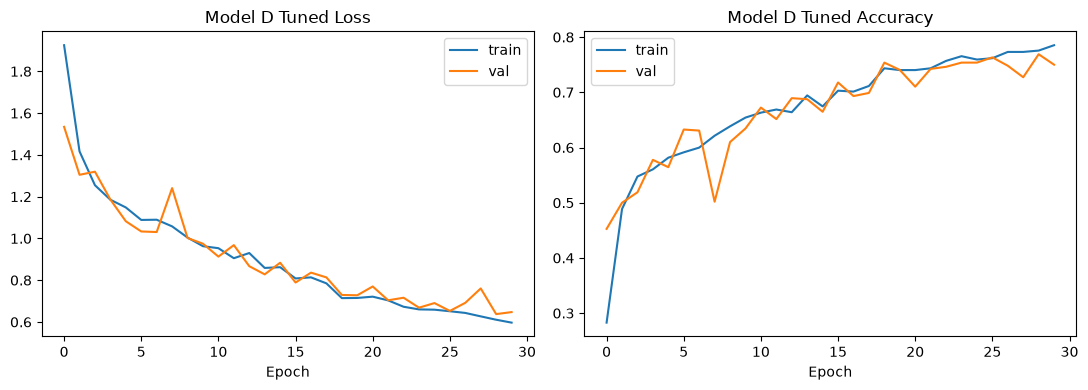

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)

axes[0].plot(
    history_d.history["loss"],
    label="train",
)

axes[0].plot(
    history_d.history["val_loss"],
    label="val",
)

axes[0].set_title("Model D Tuned Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    history_d.history["accuracy"],
    label="train",
)

axes[1].plot(
    history_d.history["val_accuracy"],
    label="val",
)

axes[1].set_title("Model D Tuned Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "model_d_tuned_curves.png",
    ),
    dpi=120,
)

plt.show()

Model D test accuracy: 0.7576 | test loss: 0.6548
Model D Macro F1: 0.7596


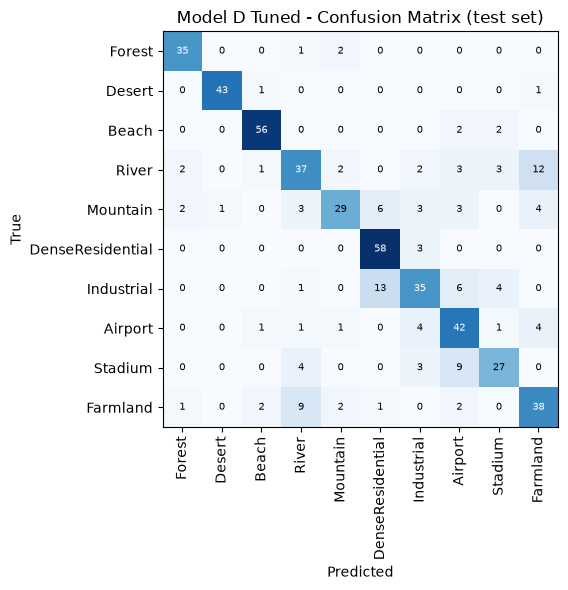

                  precision    recall  f1-score   support

          Forest       0.88      0.92      0.90        38
          Desert       0.98      0.96      0.97        45
           Beach       0.92      0.93      0.93        60
           River       0.66      0.60      0.63        62
        Mountain       0.81      0.57      0.67        51
DenseResidential       0.74      0.95      0.83        61
      Industrial       0.70      0.59      0.64        59
         Airport       0.63      0.78      0.69        54
         Stadium       0.73      0.63      0.68        43
        Farmland       0.64      0.69      0.67        55

        accuracy                           0.76       528
       macro avg       0.77      0.76      0.76       528
    weighted avg       0.76      0.76      0.75       528



In [10]:
test_loss_d, test_acc_d = model_d.evaluate(
    test_ds,
    verbose=0,
)

print(
    f"Model D test accuracy: {test_acc_d:.4f} "
    f"| test loss: {test_loss_d:.4f}"
)

y_true_d = []
y_pred_d = []

for imgs, labels in test_ds:
    probs_d = model_d.predict(
        imgs,
        verbose=0,
    )

    y_true_d.extend(
        labels.numpy().tolist()
    )

    y_pred_d.extend(
        np.argmax(
            probs_d,
            axis=1,
        ).tolist()
    )

macro_f1_d = f1_score(
    y_true_d,
    y_pred_d,
    average="macro",
)

print(
    f"Model D Macro F1: {macro_f1_d:.4f}"
)

cm_d = confusion_matrix(y_true_d, y_pred_d)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_d, cmap="Blues")

ax.set_xticks(range(len(TARGET_CLASSES)))
ax.set_xticklabels(TARGET_CLASSES, rotation=90)

ax.set_yticks(range(len(TARGET_CLASSES)))
ax.set_yticklabels(TARGET_CLASSES)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Model D Tuned - Confusion Matrix (test set)")

for i in range(cm_d.shape[0]):
    for j in range(cm_d.shape[1]):
        ax.text(
            j,
            i,
            cm_d[i, j],
            ha="center",
            va="center",
            color="white" if cm_d[i, j] > cm_d.max() / 2 else "black",
            fontsize=7,
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "model_d_tuned_confusion_matrix.png",
    ),
    dpi=120,
)

plt.show()

print(
    classification_report(
        y_true_d,
        y_pred_d,
        target_names=TARGET_CLASSES,
    )
)

In [ ]:
model_d.save(
    os.path.join(
        ARTIFACTS_DIR,
        "model_d_tuned.keras",
    )
)

model_d_params = model_d.count_params()

history_out_d = {
    "model": "model_d_tuned",
    "config": model_d_config,
    "epochs": int(epochs_completed_d),
    "train_time_sec": float(train_time_sec_d),
    "n_params": int(model_d_params),
    "test_accuracy": float(test_acc_d),
    "test_loss": float(test_loss_d),
    "macro_f1": float(macro_f1_d),
    "history": {
        k: [float(v) for v in vals]
        for k, vals in history_d.history.items()
    },
}

with open(
    os.path.join(
        RESULTS_DIR,
        "model_d_tuned_history.json",
    ),
    "w",
) as f:
    json.dump(
        history_out_d,
        f,
        indent=2,
    )

print(
    "Saved model to",
    os.path.join(
        ARTIFACTS_DIR,
        "model_d_tuned.keras",
    ),
)

print(
    "Saved training history to",
    os.path.join(
        RESULTS_DIR,
        "model_d_tuned_history.json",
    ),
)

Saved model to C:\Users\Asus\Desktop\AID-Scene_Classification\artifacts\model_d_tuned_history.json
Saved training history to C:\Users\Asus\Desktop\AID-Scene_Classification\results\model_d_tuned_history.json


## Findings

Model D Tuned retained the custom multi-scale architecture with parallel 3×3 and 5×5 convolutional branches. The training process was extended to a maximum of 30 epochs and enhanced using Early Stopping and ReduceLROnPlateau, while the architecture and number of parameters remained unchanged.

Overall, extending the training duration and dynamically reducing the learning rate improved Model D without changing its architecture. The tuned model achieved the same rounded test accuracy as Model E, but it required up to 30 epochs. Therefore, it was treated as an additional tuning experiment and was excluded from the primary 15-epoch comparison.